In [3]:
library(Seurat)
library(Signac)
library(GenomeInfoDb)
library(EnsDb.Hsapiens.v86)
library(ggplot2)
library(patchwork)
library(hdf5r)
library(future)
library(RColorBrewer)
library(dplyr)
library(Matrix)
library(BSgenome.Hsapiens.UCSC.hg38)
library(glue)
library(harmony)
library(matrixStats)
library(scales)
library(biomaRt)
library(curl)
library(goseq)
library(httr)
library(Scillus)
library(TFBSTools)
library(JASPAR2020)
library(ggridges)
library(ggrepel)
library(ggsignif)
library(qusage)
library(tidyverse)
library(effsize)
library(DESeq2)
library(cowplot)
httr::set_config(config(ssl_verifypeer = 0L))
set.seed(1234)
setwd("/home/jupyter/scATAC_analysis/edit/snatac-rcc-manuscript")
source("scripts/functions.r")


Attaching SeuratObject

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: ensembldb

Loading required packag

# Figure 5A: Coverage plots at immune recruiting loci with increased accessibility in BAP1 mutant tumor cells

Significant DAGs between BAP1 pLOF and WT ccRCC tumor cells in supp table 5A

## Read in genes differentially accessible between BAP1 mutated and BAP1 wt ccrcc-balanced tumor cells and subset to those that are immune cell recruiting. 

In [ ]:
dag <- readRDS("processed_data/ccrcc_balanced_bap1_DAGs.rds")

chemokines <- c("CXCL9", "CXCL10", "CXCL11", "CXCL12", "CCL5", "CCL2", "CCL4", "CCL20", "CCL17", "CCL22", "CSF1")
sig_chemokine_dags <- dag %>% filter(cluster == "pLOF", gene %in% chemokines, p_val_adj < 0.05)


## Create downsampled tumor cell object for making coverage plots

- Read in ccrcc-balanced tumor cell object
- Subset to samples from late stage patients with BAP1 mutation or no BAP1 mutation
- Downsample to max 1000 tumor cells per sample to create less cell count biased coverage plots

In [ ]:
ccrcc <- readRDS("processed_data/ccrcc_balanced_seurat.rds")
# BAP1_LOF annotates whether theres a pLOF mutation
groupa <- (ccrcc@meta.data %>% filter(BAP1_LOF == 1, stage %in% c(3, 4)))$new_barcodes
# BAP1 annotates whether theres any mutation (e.g., could be a missense mutation)
groupb <- (ccrcc@meta.data %>% filter(BAP1 == 0, stage %in% c(3, 4)))$new_barcodes
ccrcc <- subset(ccrcc, cells = c(groupa, groupb))
ccrcc$BAP1 <- ifelse(ccrcc$BAP1_LOF == 1, "pLOF", "WT")

Idents(ccrcc) <- "biopsy"
ccrcc_downsample <- subset(ccrcc, downsample = 1000)
saveRDS(ccrcc_downsample, "processed_data/ccrcc_balanced_bap1_mut_wt_latestage_downsamplebiopsy1000.rds")


## Create coverage plots

Warning message:
"Removed 105 rows containing missing values or values outside the scale range
(`geom_segment()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


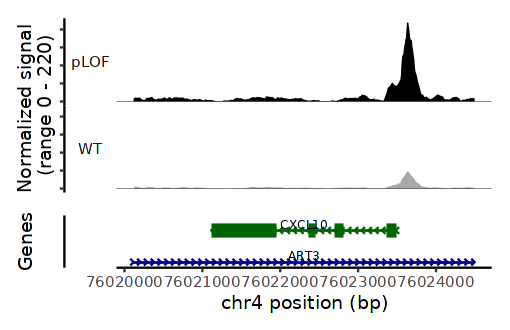

Warning message:
"Removed 105 rows containing missing values or values outside the scale range
(`geom_segment()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


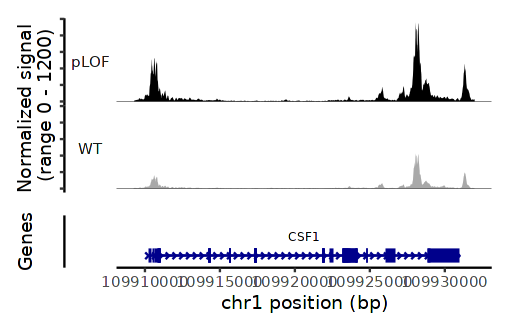

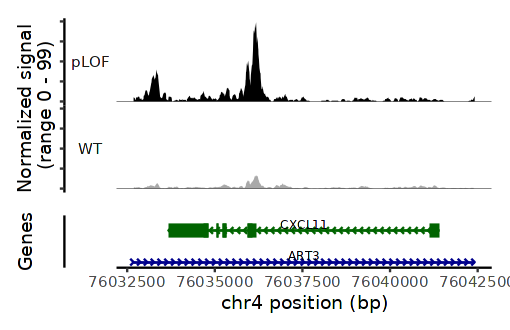

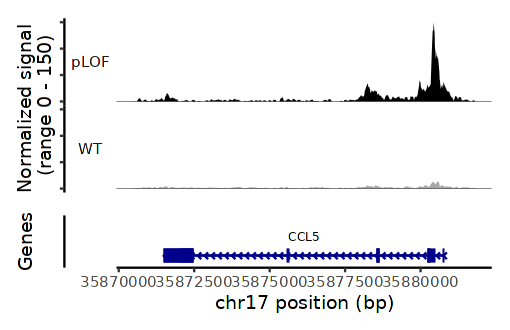

In [11]:
sig_chemokine_dags_genes <- sig_chemokine_dags$gene
for (gene in sig_chemokine_dags_genes) {
    DefaultAssay(ccrcc_downsample) <- "ATAC"
    options(repr.plot.width = 4.25, repr.plot.height = 2.75)
    plot <- CoveragePlot(ccrcc_downsample, region = gene, peaks = F, group.by = "BAP1", extend.upstream = 1000, extend.downstream = 1000) & scale_fill_manual(values = c("black", "darkgrey"))
    print(plot)
}


# Figure 5B: Boxplots of broad immune cell type proportions between BAP1 pLOF and WT samples

## Read in all cells seurat object metadata and filter
Filter to cells to QC-passing from patients with late stage clear cell ccRCC. And those that have a pLOF BAP1 mutation or are BAP1 wt. 

In [14]:
metadata <- readRDS("processed_data/allcells_seurat_metadata.rds")

metadata <- metadata %>% filter((BAP1_LOF == 1) | (BAP1 == 0))
metadata <- metadata %>% filter((broad_celltype_excluded != "Excluded") & (stage %in% c("3", "4")) & (histology == "Clear cell"))
metadata$BAP1_status <- ifelse(metadata$BAP1_LOF == 1, "pLOF", "WT")


## Calculate immune cell type proportion

In [15]:
# Grouping by cell type, biopsy, and BAP1 status
grouped_df <- metadata %>%
  group_by(broad_celltype_excluded, biopsy, BAP1_status) %>%
  summarise(cell_count = n(), .groups = "drop")

# Calculating total cells per biopsy
total_cells_per_biopsy <- grouped_df %>%
  group_by(biopsy) %>%
  summarise(total_cells = sum(cell_count), .groups = "drop")

# Merging to get total cells in each biopsy alongside each group
merged_df <- merge(grouped_df, total_cells_per_biopsy, by = "biopsy")

# Calculating the proportion
merged_df <- merged_df %>%
  mutate(proportion = cell_count / total_cells)

# Selecting relevant columns
all_everything_props <- merged_df %>%
  dplyr::select(biopsy, broad_celltype_excluded, BAP1_status, proportion, total_cells)

# Add in stage information
all_everything_props <- dplyr::left_join(all_everything_props, metadata %>% dplyr::select(c("biopsy", "stage")), by = "biopsy") %>% distinct()
all_everything_props$stage <- factor(all_everything_props$stage)


Warning message in dplyr::left_join(all_everything_props, metadata %>% dplyr::select(c("biopsy", :
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning."


Set immune cell type order and only plot immune cell types

In [16]:
all_everything_props$BAP1_status <- factor(all_everything_props$BAP1_status, levels = c("WT", "pLOF"))
immune_infiltrate_plot <- all_everything_props %>% filter(!(broad_celltype_excluded %in% c("Tumor", "Endothelial", "Perivascular cell", "Fibroblast")))
immune_infiltrate_plot$broad_celltype_excluded <- factor(immune_infiltrate_plot$broad_celltype_excluded,
    levels = rev(c("CD8 T cell", "T-helper", "T-reg", "NK", "Plasma cell", "B cell", "TAM", "Monocyte", "MoDC", "cDC"))
)


## Calculate p-value and q-values for comparisons

In [17]:
celltypes <- unique(immune_infiltrate_plot$broad_celltype_excluded)
results <- list()
for (i in 1:length(celltypes)) {
    celltype <- celltypes[i]
    celltype_meta <- immune_infiltrate_plot
    celltype_meta$broad_celltype_excluded <- as.character(celltype_meta$broad_celltype_excluded)
    celltype_meta <- celltype_meta %>% filter(broad_celltype_excluded == celltype)
    bap1_mt_prop_vector <- (celltype_meta %>% filter(BAP1_status == "pLOF"))$proportion
    bap1_wt_prop_vector <- (celltype_meta %>% filter(BAP1_status == "WT"))$proportion
    test <- wilcox.test(x = bap1_mt_prop_vector, y = bap1_wt_prop_vector)
    side <- ifelse(median(bap1_mt_prop_vector) > median(bap1_wt_prop_vector), "pLOF", "WT")
    results[[i]] <- data.frame(celltype = celltype, pvalue = test$p.value, side = side)
}

results_df <- dplyr::bind_rows(results)
results_df$padjust <- p.adjust(p = results_df$pvalue, method = "fdr")
results_df


celltype,pvalue,side,padjust
<fct>,<dbl>,<chr>,<dbl>
CD8 T cell,0.129669763,pLOF,0.43223254
MoDC,0.391296870,pLOF,0.80866193
Monocyte,0.002063983,pLOF,0.02063983
NK,0.718059856,WT,0.83141678
cDC,0.831416777,pLOF,0.83141678
T-reg,0.404330963,pLOF,0.80866193
B cell,0.826923077,pLOF,0.83141678
Plasma cell,0.825174825,pLOF,0.83141678
T-helper,0.601547988,pLOF,0.83141678


## Plot

In [18]:
immune_infiltrate_plot$BAP1_status <- factor(immune_infiltrate_plot$BAP1_status, levels = c("pLOF", "WT"))


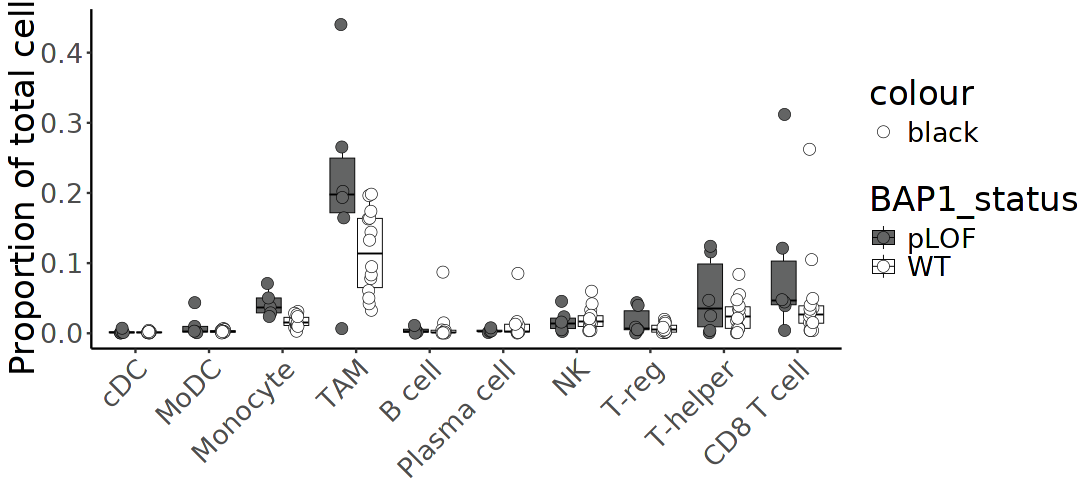

In [19]:
options(repr.plot.width = 9, repr.plot.height = 4)
immune_infiltrate_plot %>% ggplot(., aes(x = broad_celltype_excluded, y = proportion, fill = BAP1_status)) +
  geom_boxplot(outlier.shape = NA, color = "black", lwd = 0.2) +
  geom_point(position = position_jitterdodge(jitter.width = 0.1), alpha = 1, aes(color = "black"), pch = 21, stroke = 0.2, size = 3) +
  theme_classic() +
  theme(text = element_text(size = 20)) +
  theme(axis.title.x = element_blank(), axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_manual(values = c("#636464", "white")) +
  scale_color_manual(values = c("black", "white")) +
  ylab("Proportion of total cells")


# Figure 5C: CD8+ feature density between BAP1 mut and wt tumors using multiplex IF data

In [ ]:
mif_df <- read.table("processed_data/mIF_data.csv", sep = ",", check.names = F, header = T)


## Remove outliers

In [21]:
features <- c(
  "CD8+ in IT", "CD8+ in TSI",
  "CD8+PD1+ in IT", "CD8+PD1+ in TSI"
)

# Store which features each sample is an outlier for
sample_outlier_features <- list()

for (feature in features) {
  q1 <- quantile(mif_df[[feature]], 0.25, na.rm = TRUE)
  q3 <- quantile(mif_df[[feature]], 0.75, na.rm = TRUE)
  iqr <- q3 - q1
  upper_bound <- q3 + 5 * iqr
  lower_bound <- q1 - 5 * iqr

  # Find outlier samples for this feature
  extreme <- mif_df %>%
    dplyr::filter((.data[[feature]] > upper_bound) | (.data[[feature]] < lower_bound))

  for (sample_id in extreme$IP_Sample_ID) {
    sample_outlier_features[[as.character(sample_id)]] <-
      c(sample_outlier_features[[as.character(sample_id)]], feature)
  }
}

# Print samples that are outliers in more than one feature
for (sample in names(sample_outlier_features)) {
  feature_list <- sample_outlier_features[[sample]]
  if (length(feature_list) > 1) {
    cat(sprintf(
      "Sample %s is an outlier in %d features: %s\n",
      sample, length(feature_list), paste(feature_list, collapse = ", ")
    ))
  }
}


Sample CBIO_IP_P1558_S1 is an outlier in 4 features: CD8+ in IT, CD8+ in TSI, CD8+PD1+ in IT, CD8+PD1+ in TSI


In [22]:
mif_df <- mif_df %>% dplyr::filter(IP_Sample_ID != "CBIO_IP_P1558_S1")


## Normalize PD1+CD8+ by CD8+ density

In [23]:
mif_df$`CD8+PD1+_CD8+_IT_ratio` <- mif_df$`CD8+PD1+ in IT` / mif_df$`CD8+ in IT`
mif_df$`CD8+PD1+_CD8+_TSI_ratio` <- mif_df$`CD8+PD1+ in TSI` / mif_df$`CD8+ in TSI`


## Keep only ccRCC samples.

In [25]:
ccrcc_mif_df <- mif_df %>%
  dplyr::filter(
    `IP Cancer Type Detailed` == "Renal Clear Cell Carcinoma" |
      RCC_manual_subtype_annotation == "Renal Clear Cell Carcinoma"
  )


## Calculate nominal and adjusted p values

In [26]:
# CD8 features
features <- c(
  "CD8+ in IT", "CD8+ in TSI",
  "CD8+PD1+ in IT", "CD8+PD1+ in TSI",
  "CD8+PD1+_CD8+_IT_ratio", "CD8+PD1+_CD8+_TSI_ratio"
)

# compute one-sided Wilcoxon (LOF > WT) p-values per feature
pvals <- sapply(features, function(f) {
  mutated <- na.omit(ccrcc_mif_df[[f]][ccrcc_mif_df$bap1_status == "LOF"])
  wt <- na.omit(ccrcc_mif_df[[f]][ccrcc_mif_df$bap1_status == "WT"])
  if (length(mutated) > 0 && length(wt) > 0) {
    wilcox.test(mutated, wt, alternative = "greater", exact = FALSE)$p.value
  } else {
    NA_real_
  }
})

# multiple testing correction (Benjamini–Hochberg / FDR)
pvals_adj <- p.adjust(pvals, method = "BH")

# results table sorted by raw p-value
results_df <- data.frame(
  feature = features,
  pval = as.numeric(pvals),
  pval_adj = as.numeric(pvals_adj),
  stringsAsFactors = FALSE
)

results_df <- results_df[order(results_df$pval), ]
results_df


,feature,pval,pval_adj
,<chr>,<dbl>,<dbl>
3,CD8+PD1+ in IT,0.01535419,0.05905086
5,CD8+PD1+_CD8+_IT_ratio,0.01968362,0.05905086
6,CD8+PD1+_CD8+_TSI_ratio,0.03778028,0.07290082
4,CD8+PD1+ in TSI,0.04860054,0.07290082
1,CD8+ in IT,0.08742222,0.09625879
2,CD8+ in TSI,0.09625879,0.09625879


Plotting function

In [27]:
# Nice y-axis labels per row
ylab_lookup <- c(
  "CD8+ in IT" = "CD8+",
  "CD8+ in TSI" = "CD8+",
  "CD8+PD1+ in IT" = "CD8+PD1+",
  "CD8+PD1+ in TSI" = "CD8+PD1+",
  "CD8+PD1+_CD8+_IT_ratio" = "CD8+PD1+ / CD8+",
  "CD8+PD1+_CD8+_TSI_ratio" = "CD8+PD1+ / CD8+"
)

# Helper to build ONE panel
make_panel <- function(feat, show_y = TRUE, show_x = FALSE, show_legend = FALSE) {
  df_sub <- plot_df %>% dplyr::filter(feature == feat)

  # per-panel y position & label from q-values (results_df$pval_adj)
  y_max <- suppressWarnings(max(df_sub$value, na.rm = TRUE))
  y_pos <- if (is.finite(y_max)) y_max * 1.08 else NA_real_

  qv <- results_df %>%
    dplyr::filter(feature == feat) %>%
    summarise(pval_adj = if (n() == 0) NA_real_ else pval_adj[1]) %>%
    pull(pval_adj)
  lab <- sprintf("q=%.2g", ifelse(is.na(qv), 1, qv))

  pval_annot <- tibble::tibble(
    label = lab,
    group1 = "LOF",
    group2 = "WT",
    y_pos = y_pos
  )

  p <- ggplot(df_sub, aes(x = bap1_status, y = value)) +
    geom_boxplot(aes(fill = bap1_status),
      outlier.shape = NA, color = "black",
      na.rm = TRUE, show.legend = FALSE
    ) +
    scale_fill_manual(values = c(LOF = "#636464", WT = "white")) +
    ggnewscale::new_scale_fill() +
    geom_point(
      aes(shape = lymphoid, fill = io_exposed),
      position = position_jitter(width = 0.12, height = 0, seed = 123),
      size = 3, stroke = 0.2, color = "black", na.rm = TRUE,
      show.legend = show_legend
    ) +
    scale_shape_manual(values = c("Lymph node biopsy" = 24, "Other biopsy site" = 21)) +
    scale_fill_manual(values = c("IO exposed" = "red", "IO naïve" = "white")) +
    ggpubr::stat_pvalue_manual(
      data = pval_annot,
      label = "label", xmin = "group1", xmax = "group2",
      y.position = "y_pos",
      bracket.size = 0.3, size = 4.5, inherit.aes = FALSE
    ) +
    labs(
      x = if (show_x) "BAP1 Status" else NULL,
      y = if (show_y) ylab_lookup[[feat]] else NULL
    ) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
    theme_bw() +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major = element_blank(),
      panel.border = element_blank(),
      axis.line = element_line(color = "black"),
      axis.title.y = if (show_y) element_text() else element_blank(),
      axis.text.y = if (show_y) element_text() else element_blank(),
      axis.ticks.y = if (show_y) element_line() else element_blank(),
      axis.title.x = if (show_x) element_text() else element_blank(),
      axis.text.x = if (show_x) element_text() else element_blank(),
      axis.ticks.x = if (show_x) element_line() else element_blank(),
      legend.position = if (show_legend) "right" else "none",
      text = element_text(size = 14)
    )
  p
}


## Plot

Warning message in get_plot_component(plot, "guide-box"):
"Multiple components found; returning the first one. To return all, use `return_all = TRUE`."


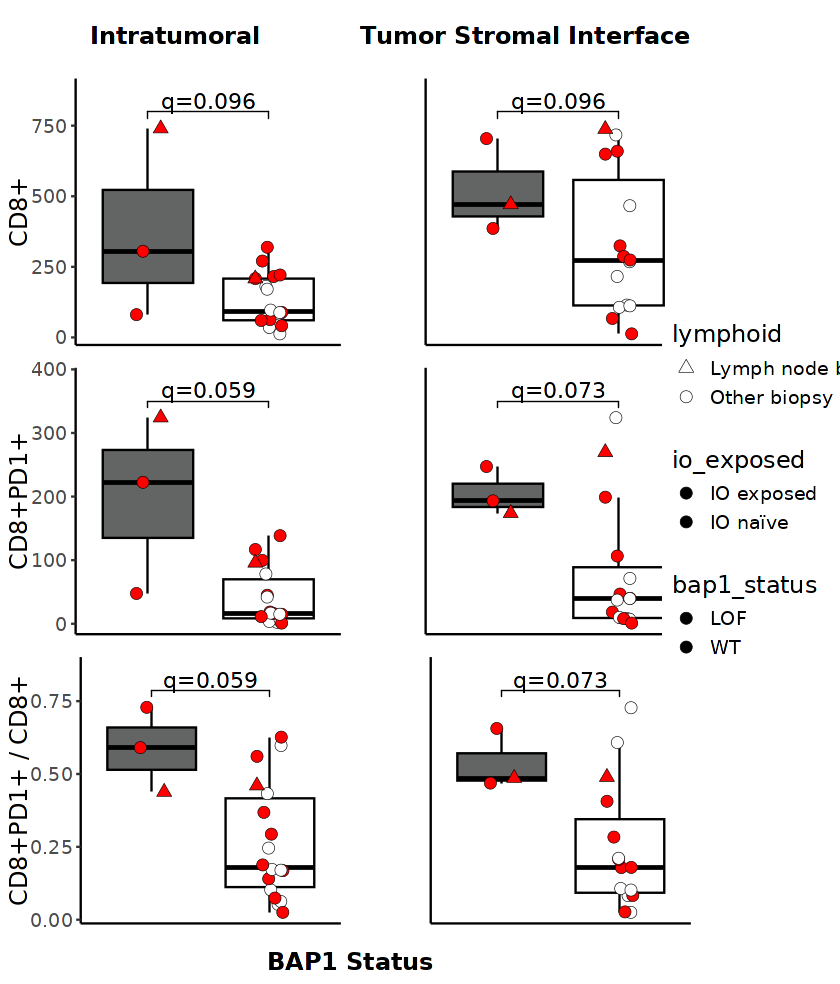

In [33]:
# cd8 features
features <- c(
  "CD8+ in IT", "CD8+ in TSI",
  "CD8+PD1+ in IT", "CD8+PD1+ in TSI",
  "CD8+PD1+_CD8+_IT_ratio", "CD8+PD1+_CD8+_TSI_ratio"
)

# format data
plot_df <- ccrcc_mif_df %>%
  mutate(
    bap1_status = factor(bap1_status, levels = c("LOF", "WT")),
    lymphoid = factor(
      ifelse(`IP Oncotree Biopsy Site` == "LYMPHOID", "Lymph node biopsy", "Other biopsy site"),
      levels = c("Lymph node biopsy", "Other biopsy site")
    ),
    io_exposed = factor(
      ifelse(`IO exposure` == "Yes", "IO exposed", "IO naïve"),
      levels = c("IO exposed", "IO naïve")
    )
  ) %>%
  pivot_longer(all_of(features), names_to = "feature", values_to = "value")


# turn off x-axis labels in make_panel
p1 <- make_panel("CD8+ in IT", show_y = TRUE, show_x = FALSE)
p2 <- make_panel("CD8+ in TSI", show_y = FALSE, show_x = FALSE)
p3 <- make_panel("CD8+PD1+ in IT", show_y = TRUE, show_x = FALSE)
p4 <- make_panel("CD8+PD1+ in TSI", show_y = FALSE, show_x = FALSE)
p5 <- make_panel("CD8+PD1+_CD8+_IT_ratio", show_y = TRUE, show_x = FALSE)
p6 <- make_panel("CD8+PD1+_CD8+_TSI_ratio", show_y = FALSE, show_x = FALSE)
p6_with_legend <- make_panel("CD8+PD1+_CD8+_TSI_ratio",
  show_y = FALSE, show_x = TRUE, show_legend = TRUE
)
legend_grob <- cowplot::get_legend(p6_with_legend)

# build the 3×2 grid
grid_3x2 <- plot_grid(
  plot_grid(p1, p2, ncol = 2, align = "hv", axis = "lrtb"),
  plot_grid(p3, p4, ncol = 2, align = "hv", axis = "lrtb"),
  plot_grid(p5, p6, ncol = 2, align = "hv", axis = "lrtb"),
  ncol = 1, align = "v", axis = "lrtb"
)

# add column headers (unchanged)
column_titles <- plot_grid(
  ggdraw() + draw_label("Intratumoral", fontface = "bold", hjust = 0.5, size = 14),
  ggdraw() + draw_label("Tumor Stromal Interface", fontface = "bold", hjust = 0.5, size = 14),
  ncol = 2
)

grid_with_titles <- plot_grid(column_titles, grid_3x2,
  ncol = 1, rel_heights = c(0.08, 1)
)

# add a shared x-axis label underneath
grid_with_xlabel <- plot_grid(
  grid_with_titles,
  ggdraw() + draw_label("BAP1 Status", fontface = "bold", size = 14, hjust = 0.5),
  ncol = 1, rel_heights = c(1, 0.05)
)

# combine with legend
final_plot <- plot_grid(grid_with_xlabel, legend_grob,
  ncol = 2, rel_widths = c(1, 0.2)
)


options(repr.plot.width = 7, repr.plot.height = 8.2)
print(final_plot)


# Figure 5D: Selected mIF ROIs from two BAP1 pLOF and two BAP1 WT samples for visualization purposes

Selected two ROIs frmo BAP1 mutant samples and two from BAP1 wt samples. One lymph node and lung site each, all IO exposed. All intratumoral regions. See paper. 

# Figure 5E: Coverage plots at immune evasion and checkpoint genes with increased accessibility in BAP1 mutated tumor cells
Significant DAGs between BAP1 pLOF and WT ccRCC tumor cells in supp table 5A

## Read in genes differentially accessible between BAP1 mutated and BAP1 wt ccrcc-balanced tumor cells and subset to those that are immune checkpoint and evasion genes. 

In [ ]:
dag <- readRDS("processed_data/ccrcc_balanced_bap1_DAGs.rds")

immune_evasion_and_checkpoints <- c(
  "CD274",
  "PDCD1LG2",
  "C10orf54",
  "LGALS9",
  "MIF",
  "VSIG4",
  "HLA-E",
  "NECTIN2",
  "PVR",
  "CD276",
  "NT5E",
  "ENTPD1",
  "VTCN1",
  "HLA-G",
  "IDO1"
)

sig_imm_dags <- dag %>% filter(cluster == "pLOF", gene %in% immune_evasion_and_checkpoints, p_val_adj < 0.05)


## Read in downsampled tumor cell object and make coverage plots

*Note: Downsampled object created above in section Figure 5A*

ccrcc-balanced tumor cells from late stage ccRCC patients, BAP1 WT or with pLOF mutation. Downsampled to max 1000 tumor cells per sample. 

In [ ]:
ccrcc_downsample <- readRDS("processed_data/ccrcc_balanced_bap1_mut_wt_latestage_downsamplebiopsy1000.rds")


Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_segment()`)."


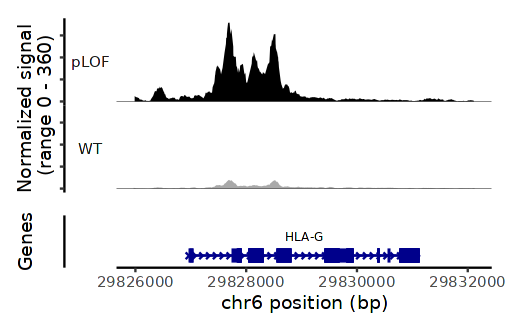

Warning message:
"Removed 373 rows containing missing values or values outside the scale range
(`geom_segment()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


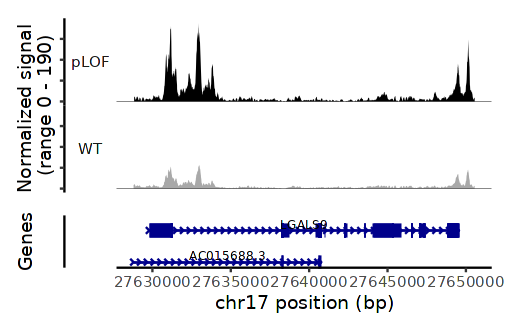

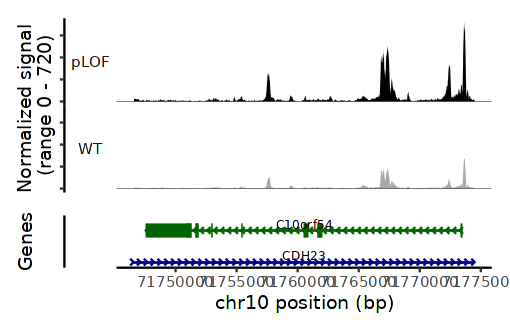

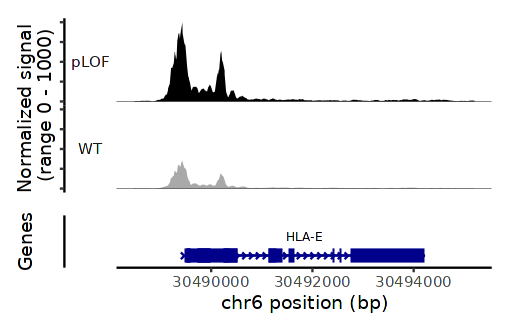

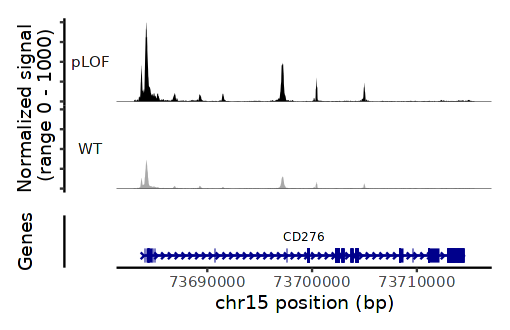

: 

In [ ]:
sig_imm_dags_genes <- sig_imm_dags$gene
for (gene in sig_imm_dags_genes) {
    DefaultAssay(ccrcc_downsample) <- "ATAC"
    options(repr.plot.width = 4.25, repr.plot.height = 2.75)
    plot <- CoveragePlot(ccrcc_downsample, region = gene, peaks = F, group.by = "BAP1", extend.upstream = 1000, extend.downstream = 1000) & scale_fill_manual(values = c("black", "darkgrey"))
    print(plot)
}
